# 06 · The deployable artefact — `MonitoringPipeline`

Notebooks 02-05 explore each layer in isolation. What ships to the plant is **one object** that bundles the scaler, the detectors, the classifier, the RUL head, the calibrated thresholds, the cost model and a drift monitor. This notebook fits it, evaluates it on held-out runs, serialises it, and scores a fresh batch — the same path `sensorlab train` and `sensorlab score` take from the command line.

In [1]:
import sensorlab  # set OMP env vars before torch/xgboost load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})


In [2]:
from sensorlab.data import load_dataset, SyntheticTEPConfig, train_val_test_split_by_run
from sensorlab.pipeline import MonitoringPipeline, PipelineConfig
from sensorlab.decision import CostModel

cfg = SyntheticTEPConfig(n_normal_runs=12, n_runs_per_fault=4, fault_run_minutes=480, seed=0)
ds = load_dataset("synthetic", cfg=cfg)
train_m, val_m, test_m = train_val_test_split_by_run(ds, seed=0)

pipe = MonitoringPipeline(PipelineConfig(
    ae_epochs=15,
    cost=CostModel(false_alarm_cost=100, missed_fault_cost=5000, delay_cost_per_min=50),
    intervene_horizon_min=120,
)).fit(ds, train_m, val_m)
print("primary detector:", pipe.primary_detector_)
print("FAR thresholds:", {k: round(v, 3) for k, v in pipe.far_thresholds_.items()})
print("operating thresholds (cost-optimal on validation):",
      {k: round(v, 3) for k, v in pipe.decision_thresholds_.items()})

primary detector: IForest
FAR thresholds: {'PCA-T2Q': 20.41, 'IForest': 0.587, 'LSTM-AE': 1.801}
operating thresholds (cost-optimal on validation): {'PCA-T2Q': 4.099, 'IForest': 0.498, 'LSTM-AE': 0.802}


## Held-out evaluation of every layer

Thresholds were fixed on validation; everything below is measured on the test runs only.

In [3]:
res = pipe.evaluate(ds, test_m, shap_samples=0)
det = pd.DataFrame(res["detection"]).T[["auroc", "tpr_at_far", "far_observed", "fraction_detected", "median_delay_min"]]
dec = pd.DataFrame(res["decision"]).T[["threshold", "expected_cost", "false_alarms", "missed_faults", "mean_delay_min"]]
display(det.round(3)); display(dec.round(2))
print("diagnosis:", {k: round(v, 3) for k, v in res["diagnosis"].items() if isinstance(v, float)})
print("rul:      ", {k: round(v, 2) for k, v in res["rul"].items() if isinstance(v, float)})
print("actions:  ", res["actions"])

,auroc,tpr_at_far,far_observed,fraction_detected,median_delay_min
PCA-T2Q,0.757,0.145,0.007,0.524,48.0
IForest,0.842,0.375,0.003,0.762,46.5
LSTM-AE,0.924,0.567,0.000,0.952,48.0


,threshold,expected_cost,false_alarms,missed_faults,mean_delay_min
PCA-T2Q,4.1,60150.0,459.0,0.0,13.57
IForest,0.5,41350.0,226.0,0.0,17.86
LSTM-AE,0.8,66450.0,558.0,0.0,10.14


diagnosis: {'accuracy': 0.697, 'balanced_accuracy': 0.638, 'macro_f1': 0.633, 'fit_seconds': 87.91}
rul:       {'mae_minutes': 93.73, 'coverage_80': 0.83, 'coverage_80_uncalibrated': 0.59, 'conformal_margin_min': 30.55, 'pinball_50': 46.86, 'mean_interval_width_min': 281.48, 'fit_seconds': 1.54}
actions:   {'alarm_precision': 0.94026284348865, 'alarm_recall': 0.6246031746031746, 'action_counts': {'wait': 2166, 'schedule_maintenance': 1364, 'intervene_now': 188, 'investigate': 122}}


## Scoring a batch — what the operator sees

One row per sample: scores, *confirmed* alarm (three consecutive samples above the operating threshold), diagnosed fault, RUL interval and a recommended action.

In [4]:
test_runs = np.unique(ds.run_id[test_m])
run = int([r for r in test_runs if ds.run_fault_id[r] == 13][0])   # a slow-drift fault in the test split
m = ds.run_id == run
out = pipe.predict(ds.X[m], ds.run_id[m])
onset = int(ds.run_onsets[run])
first = out.index[out["alarm"] & (out.index >= onset)].min()
print(f"run {run} ({ds.fault_names[13]}): onset at {onset*3} min, first confirmed alarm at {first*3} min")
out.loc[[onset - 2, onset, first, first + 10, len(out) - 1],
        ["t_minutes", "primary_score", "alarm", "fault_name_pred", "fault_confidence",
         "rul_p10_min", "rul_p50_min", "rul_p90_min", "action"]]

run 62 (F13_reaction_kinetics_slow_drift): onset at 120 min, first confirmed alarm at 150 min


,t_minutes,primary_score,alarm,fault_name_pred,fault_confidence,rul_p10_min,rul_p50_min,rul_p90_min,action
38,114.0,0.407409,False,Normal,0.995510,32.803546,249.920579,364.855853,wait
40,120.0,0.417886,False,Normal,0.989081,37.183083,268.867040,373.010951,wait
50,150.0,0.538784,True,Normal,0.964848,41.560183,218.049760,354.734879,investigate
60,180.0,0.446363,False,Normal,0.906562,23.165209,189.409849,337.237875,wait
159,477.0,0.626048,True,F13_reaction_kinetics_slow_drift,0.565174,22.221946,146.625596,280.967804,schedule_maintenance


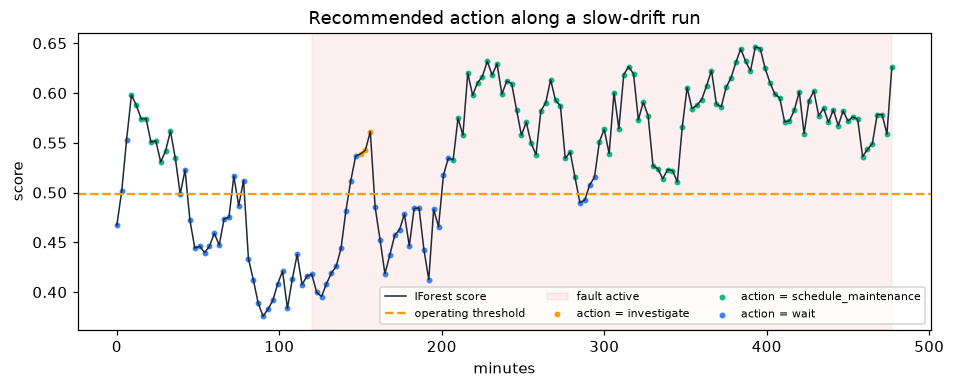

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(out["t_minutes"], out["primary_score"], color="#1f2937", lw=1, label=f"{pipe.primary_detector_} score")
ax.axhline(out["threshold"].iloc[0], color="#f59e0b", ls="--", label="operating threshold")
ax.axvspan(onset * 3, out["t_minutes"].iloc[-1], color="#ef4444", alpha=0.08, label="fault active")
colours = {"wait": "#3b82f6", "investigate": "#f59e0b", "schedule_maintenance": "#10b981", "intervene_now": "#ef4444"}
for action, g in out.groupby("action"):
    ax.scatter(g["t_minutes"], g["primary_score"], s=8, color=colours[action], label=f"action = {action}")
ax.set_xlabel("minutes"); ax.set_ylabel("score"); ax.legend(fontsize=7, ncol=3)
ax.set_title("Recommended action along a slow-drift run"); plt.show()

## Save, reload, and check for drift

`save` writes the pipeline plus a JSON manifest (config, thresholds, sensor layout, fit report). The drift monitor stores a compact reference of training-normal marginals and reports a per-sensor PSI on any new batch — the first thing to check when alarms start looking odd.

In [6]:
import tempfile, json, pathlib
tmp = pathlib.Path(tempfile.mkdtemp())
path = pipe.save(tmp / "pipeline.joblib")
reloaded = MonitoringPipeline.load(path)
manifest = json.loads(path.with_suffix(".manifest.json").read_text())
print("manifest keys:", list(manifest))
assert reloaded.predict(ds.X[m], ds.run_id[m]).equals(out)

normal_test = ds.run_mask([r for r in np.unique(ds.run_id[test_m]) if ds.run_fault_id[r] == 0])
print("drift on normal test runs:", reloaded.check_drift(ds.X[normal_test]).status)
recal = ds.X[normal_test].copy(); recal[:, 3] += 2 * ds.X[:, 3].std()   # sensor 4 recalibrated
rep = reloaded.check_drift(recal)
print("after recalibrating XMEAS(4):", rep.status, "→ alert on", rep.alert)

manifest keys: ['sensorlab_version', 'fitted_at', 'config', 'sensor_names', 'n_sensors', 'fault_names', 'sample_minutes', 'primary_detector', 'far_thresholds', 'decision_thresholds', 'fit_report']
drift on normal test runs: stable
after recalibrating XMEAS(4): alert → alert on ['XMEAS(4)']


**Takeaways**

- One fitted object + one manifest is the hand-over unit; `sensorlab score --input batch.csv --drift` runs it in a scheduled job.
- The operating threshold is chosen on validation at the business's cost mix, and its cost is reported on test — no peeking.
- The action column is the contract with operations: `wait` / `investigate` / `schedule_maintenance` / `intervene_now`, decided by the confirmed alarm, the diagnosed fault and the RUL median against a horizon the plant sets.
- Drift monitoring answers the question every deployment eventually gets: *is the model wrong, or did the plant change?*